In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("../data/tarkwa_monthly_clean.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

values = df["Monthly_Rainfall_mm"].values.reshape(-1, 1)

# Scale to 0-1 range (matches Chapter 3 §3.10's Min-Max normalisation)
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

# Build sequences: use the past 12 months to predict the next 1 month
SEQUENCE_LENGTH = 12

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_values, SEQUENCE_LENGTH)

print("X shape:", X.shape, "→ (samples, timesteps, features)")
print("y shape:", y.shape)

# Date-based split, same Jan 2015 boundary as XGBoost — accounting for
# the 12 months "lost" to building the first sequence
dates_for_y = df["Date"].iloc[SEQUENCE_LENGTH:].reset_index(drop=True)
split_idx = dates_for_y[dates_for_y >= "2015-01-01"].index[0]

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTrain: {len(X_train)} sequences, ending {dates_for_y.iloc[split_idx-1].date()}")
print(f"Test:  {len(X_test)} sequences, starting {dates_for_y.iloc[split_idx].date()}")

X shape: (273, 12, 1) → (samples, timesteps, features)
y shape: (273, 1)

Train: 216 sequences, ending 2014-12-01
Test:  57 sequences, starting 2015-01-01


In [2]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build the LSTM model
model = tf.keras.Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

# Early stopping: stops training if validation loss stops improving
# for 10 consecutive epochs — prevents overfitting without us having
# to guess the exact right number of epochs manually
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("\nTraining LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")

c:\Users\USER\Desktop\droplet_ai\droplet_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0614 - val_loss: 0.0332
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0433 - val_loss: 0.0369
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0415 - val_loss: 0.0322
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0424 - val_loss: 0.0329
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0415 - val_loss: 0.0327
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0411 - val_loss: 0.0340
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0424 - val_loss: 0.0332
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0410 - val_loss: 0.0318
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0419 - val_loss: 0.0329
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0407 - val_loss: 0.0320
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0421 - val_loss: 0.0328
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict on test set (still in scaled 0-1 space)
y_pred_scaled = model.predict(X_test)

# Inverse transform back to mm — essential before computing metrics
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100
r2 = r2_score(y_test_actual, y_pred)

print("LSTM Test Set Performance:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")

print("\nYour reference LSTM metrics were: RMSE 94.36, MAE 71.21, MAPE 229.45%, R² 0.2949")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
LSTM Test Set Performance:
  RMSE: 99.88
  MAE:  73.91
  MAPE: 259.53%
  R²:   0.2048

Your reference LSTM metrics were: RMSE 94.36, MAE 71.21, MAPE 229.45%, R² 0.2949


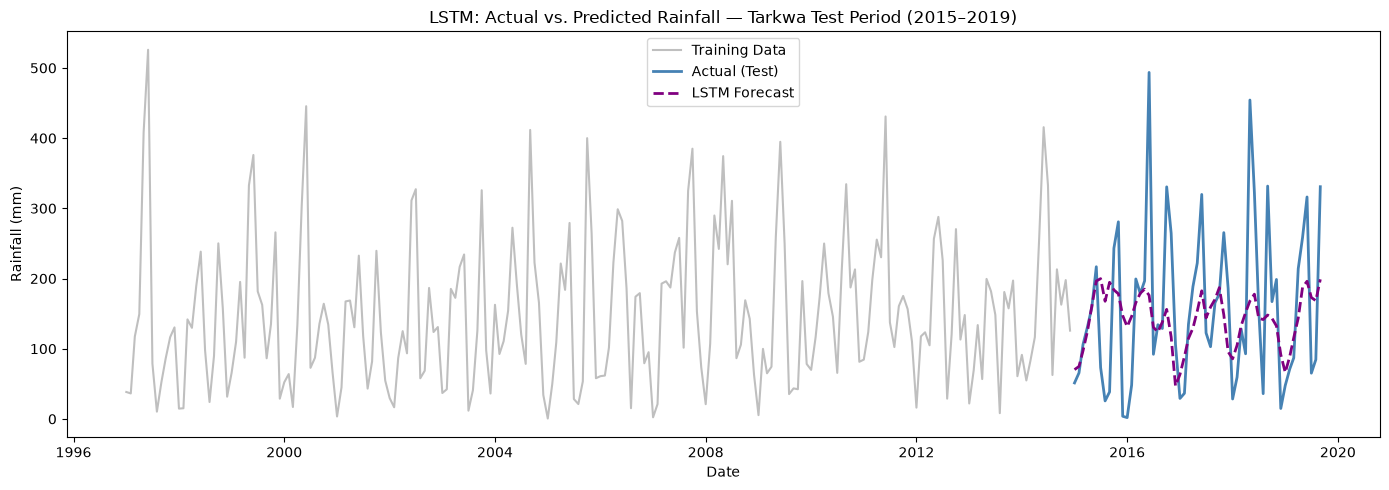

In [4]:
import matplotlib.pyplot as plt

test_dates = dates_for_y.iloc[split_idx:].reset_index(drop=True)
train_dates = dates_for_y.iloc[:split_idx].reset_index(drop=True)
y_train_actual = scaler.inverse_transform(y_train)

plt.figure(figsize=(14, 5))
plt.plot(train_dates, y_train_actual, label="Training Data", color="gray", alpha=0.5)
plt.plot(test_dates, y_test_actual, label="Actual (Test)", color="steelblue", linewidth=2)
plt.plot(test_dates, y_pred, label="LSTM Forecast", color="purple", linewidth=2, linestyle="--")

plt.title("LSTM: Actual vs. Predicted Rainfall — Tarkwa Test Period (2015–2019)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/lstm_actual_vs_predicted.png", dpi=150)
plt.show()

In [5]:
import joblib

# Save the Keras model in native format
MODEL_PATH = "../models/lstm_model.keras"
model.save(MODEL_PATH)
print(f"LSTM model saved to {MODEL_PATH}")

# Save the scaler — critically important, must be kept alongside the model
# since any prediction the backend makes needs to be inverse-transformed
# using the exact same scaler that was fit on the training data
SCALER_PATH = "../models/lstm_scaler.pkl"
joblib.dump(scaler, SCALER_PATH)
print(f"Scaler saved to {SCALER_PATH}")

# Reload check — confirm both files work together
loaded_model = tf.keras.models.load_model(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)

# Run a quick prediction using the last sequence from the test set
test_seq = X_test[-1:] 
pred_scaled = loaded_model.predict(test_seq, verbose=0)
pred_mm = loaded_scaler.inverse_transform(pred_scaled)
print(f"\nReload check — prediction from last test sequence: {pred_mm[0][0]:.2f} mm")
print("Both model and scaler reloaded successfully")

LSTM model saved to ../models/lstm_model.keras
Scaler saved to ../models/lstm_scaler.pkl

Reload check — prediction from last test sequence: 198.86 mm
Both model and scaler reloaded successfully
